In [ ]:
!pip install yfinance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import yfinance as yf  # para baixar dados de ações

In [9]:
df = yf.download(["NVDA", "AAPL", "MSFT"], start='2018-01-01')
df

/tmp/ipython-input-3245926515.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(["NVDA", "AAPL", "MSFT"], start='2018-01-01')
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        MSFT        NVDA        AAPL        MSFT   
Date                                                                     
2018-01-02   40.380997   79.198341    4.928809   40.390375   79.530063   
2018-01-03   40.373970   79.566910    5.253191   40.917824   79.714345   
2018-01-04   40.561497   80.267204    5.280882   40.664642   80.774003   
2018-01-05   41.023312   81.262352    5.325634   41.110045   81.465071   
2018-01-08   40.870930   81.345299    5.488814   41.166296   81.621736   
...                ...         ...         ...         ...         ...   
2025-10-10  245.270004  510.959991  183.160004  256.380005  523.580017   
2025-10-13  247.660004  514.049988  188.320007  249.690002  516.409973   
2025-10-14  247.770004  513.570007  180.029999  248.850006  515.280029   
2025-10-15  249.339996  513.429993  179.830002  251.820007  517.190002   
2025-10-16  247.449997  511.609985  181.809998  249.039993  516.849976   

Price                          Low                                Open  \
Ticker            NVDA        AAPL        MSFT        NVDA        AAPL   
Date                                                                     
2018-01-02    4.932518   39.677740   78.783693    4.808896   39.888719   
2018-01-03    5.283602   40.310679   79.216763    5.037594   40.444296   
2018-01-04    5.391153   40.338800   79.769622    5.258630   40.446630   
2018-01-05    5.362968   40.566195   80.562051    5.218825   40.657619   
2018-01-08    5.562987   40.772471   80.718715    5.404256   40.870930   
...                ...         ...         ...         ...         ...   
2025-10-10  195.619995  244.000000  509.630005  182.050003  254.940002   
2025-10-13  190.110001  245.559998  511.679993  185.960007  249.380005   
2025-10-14  184.800003  244.699997  506.000000  179.699997  246.600006   
2025-10-15  184.869995  247.470001  510.000000  177.289993  249.490005   
2025-10-16  183.279999  245.130005  508.130005  179.770004  248.270004   

Price                                  Volume                       
Ticker            MSFT        NVDA       AAPL      MSFT       NVDA  
Date                                                                
2018-01-02   79.364202    4.840543  102223600  22483800  355616000  
2018-01-03   79.299689    5.046248  118071600  26061400  914704000  
2018-01-04   79.788048    5.334535   89738400  21912000  583268000  
2018-01-05   80.773987    5.295718   94640000  23407100  580124000  
2018-01-08   81.271581    5.449255   82271200  22113000  881216000  
...                ...         ...        ...       ...        ...  
2025-10-10  519.640015  193.509995   61999100  24133800  268774400  
2025-10-13  516.409973  187.970001   38142900  14284200  153482800  
2025-10-14  510.230011  184.770004   35478000  14684300  205641400  
2025-10-15  514.960022  184.800003   33893600  14694700  214450500  
2025-10-16  512.729980  182.190002   39218197  15053456  178675226  

[1959 rows x 15 columns]

In [10]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            (  'Open', 'NVDA'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

<Axes: xlabel='Date'>

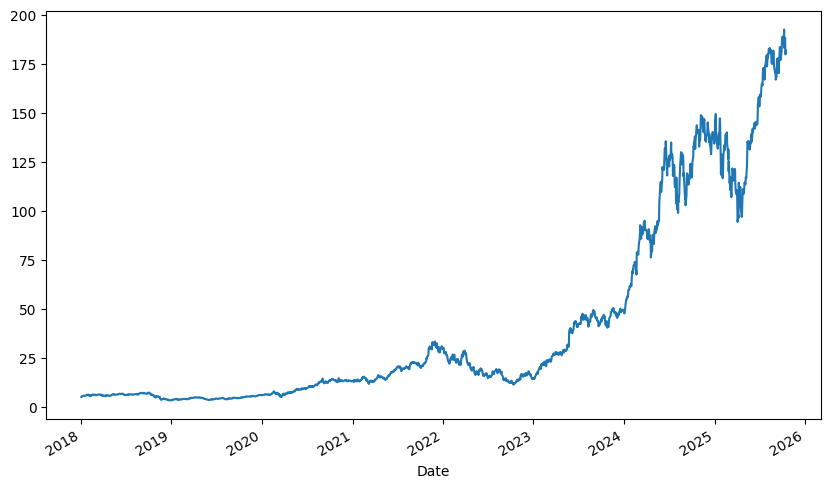

In [11]:
df[('Close', "NVDA")].plot(figsize=(10, 6))

In [12]:
def series_to_supervised(data, n_lags=5):
    """
    Converte array 1D em matriz (X, y) onde X contém lags e y é valor futuro (um passo).
    """
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [13]:
X, y = series_to_supervised(df[('Close', "AAPL")].values, n_lags=5)
X


array([[ 40.3809967 ,  40.37397003,  40.56149673,  41.02331161,
         40.87092972],
       [ 40.37397003,  40.56149673,  41.02331161,  40.87092972,
         40.86624146],
       [ 40.56149673,  41.02331161,  40.87092972,  40.86624146,
         40.85686111],
       ...,
       [256.48001099, 258.05999756, 254.03999329, 245.27000427,
        247.66000366],
       [258.05999756, 254.03999329, 245.27000427, 247.66000366,
        247.77000427],
       [254.03999329, 245.27000427, 247.66000366, 247.77000427,
        249.33999634]])

In [14]:
y

array([ 40.86624146,  40.85686111,  41.08895111, ..., 247.77000427,
       249.33999634, 247.44999695])

In [24]:
def train_and_eval_ml(symbol="AAPL", start="2018-01-01", end="2023-01-01", n_lags=21):
    # baixar série de fechamento ajustado
    df = yf.download(symbol, start=start, end=end)
    series = df[('Close', symbol)].dropna().values

    # converter para dados supervisionados
    X, y = series_to_supervised(series, n_lags=n_lags)

    # dividir treino/teste (por exemplo 80/20)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # escalar (importante para SVR)
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_test_s = scaler_x.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
    # notamos que o y_test será comparado no espaço original, então convert de volta depois

    # Regressão Linear
    model_lr = LinearRegression()
    model_lr.fit(X_train_s, y_train_s)

    # SVR
    model_svr = SVR(kernel='rbf', C=100, gamma='auto', max_iter=500)
    model_svr.fit(X_train_s, y_train_s)

    # fazer predições (em escala) e inverter escala
    y_pred_lr_s = model_lr.predict(X_test_s)
    y_pred_svr_s = model_svr.predict(X_test_s)
    y_pred_lr = scaler_y.inverse_transform(y_pred_lr_s.reshape(-1,1)).ravel()
    y_pred_svr = scaler_y.inverse_transform(y_pred_svr_s.reshape(-1,1)).ravel()

    # avaliar
    def eval_metrics(y_true, y_pred, model_name="Model"):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        print(f"{model_name}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    eval_metrics(y_test, y_pred_lr, "Linear Regression")
    eval_metrics(y_test, y_pred_svr, "SVR")

    # gráficos
    plt.figure(figsize=(12,5))
    plt.plot(range(len(y_test)), y_test, label="Real")
    plt.plot(range(len(y_test)), y_pred_lr, label="LR Predito")
    plt.plot(range(len(y_test)), y_pred_svr, label="SVR Predito")
    plt.legend()
    plt.title(f"Comparação: real vs preditos ({symbol})")
    plt.show()

    # gráfico de erros (resíduos)
    plt.figure(figsize=(12,4))
    plt.plot(y_test - y_pred_lr, label="Erro LR")
    plt.plot(y_test - y_pred_svr, label="Erro SVR")
    plt.legend()
    plt.title("Resíduos (y_true – y_pred)")
    plt.show()

    return {
        'y_test': y_test,
        'y_pred_lr': y_pred_lr,
        'y_pred_svr': y_pred_svr,
        'model_lr': model_lr,
        'model_svr': model_svr,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y
    }


/tmp/ipython-input-2483502066.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Linear Regression: RMSE = 3.6032, MAE = 2.4782
SVR: RMSE = 42.9584, MAE = 30.1340


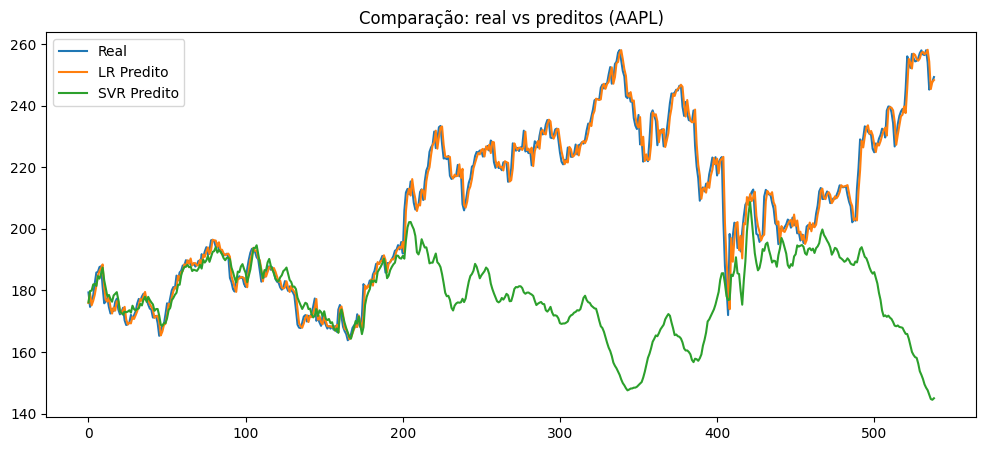

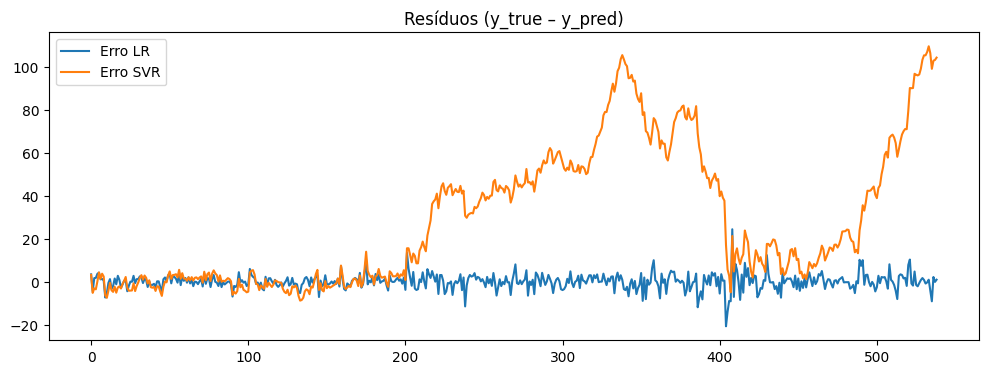

In [26]:
res = train_and_eval_ml("AAPL", start="2015-01-01", end="2025-10-16", n_lags=21)

# Exercícios

## 1) Mudança de série temporal

Substitua o ativo financeiro utilizado. Lembre-se de ajustar os parâmetros de data se necessário.

---

## 2) Comparação de modelos

Altere o modelo SVR para utilizar diferentes kernels:
- `'linear'`
- `'poly'`
- `'rbf'`

Compare os resultados entre os modelos (MLR + SVRs com diferentes kernels) utilizando métricas de erro (RMSE, MAE) e gráficos.

---

## 3) Experimentação com diferentes janelas

Execute novamente os modelos utilizando diferentes tamanhos de janela (`n_lags`):
- 5
- 10
- 20

Analise e explique os impactos da mudança no desempenho dos modelos.

---

## 4) Introdução de múltiplas variáveis

Expanda a matriz de atributos para incluir também:
- `Volume`
- `High`
- `Low`

Transforme seu problema de regressão univariada em multivariada e observe se há melhoria nas predições.